# 2. MNIST: 이미지를 한 줄씩 읽고 숫자 판단하기

이번에는 손글씨 숫자 이미지를 LSTM으로 분류합니다. CNN이 이미지의 작은 영역들을 함께 처리하는 것과 달리, 이 모델은 위에서 아래로 한 행씩 읽습니다. 두 번째 행을 처리할 때는 첫 번째 행에서 계산한 정보를 함께 사용하고, 이 과정을 마지막 행까지 반복합니다.

MNIST는 원래 시간에 따라 들어오는 데이터가 아닙니다. 여기서는 이미지의 행 순서를 읽는 순서로 정해 RNN 입력을 구성합니다. 마지막 행까지 읽은 결과로 0~9 중 어떤 숫자인지 판단합니다.

## 2-1. 입력 방식과 학습 설정

이미지 한 장은 28행 28열입니다. 한 행에 있는 픽셀 28개를 한 번에 입력하고, 이를 28번 반복합니다. 그래서 `input_size`는 28, `sequence_length`도 28입니다. 두 값은 우연히 같지만 하나는 한 번에 읽는 양, 다른 하나는 읽는 횟수를 뜻합니다.

모델이 각 단계의 정보를 나타내는 벡터를 hidden state라고 합니다. `hidden_size=128`은 그 벡터에 128개 숫자를 사용한다는 뜻입니다. 숫자가 커지면 모델 규모도 커지지만 정확도가 반드시 좋아지는 것은 아닙니다.

| 설정 | 이번 학습에서 정하는 것 |
|---|---|
| `num_layers=10` | LSTM 층을 10개 쌓습니다. 이미지의 28개 행을 읽는 횟수와는 별개입니다. |
| `num_classes=10` | 숫자 0~9에 대해 점수 10개를 출력합니다. |
| `batch_size=50` | 이미지 50장을 묶어 한 번의 업데이트에 사용합니다. |
| `num_epochs=3` | 전체 학습 이미지를 세 번 사용합니다. |
| `learning_rate=0.001` | 가중치 업데이트 크기를 조절합니다. |

첫 줄에서는 사용 가능한 계산 장치를 선택합니다. 뒤에서는 이 장치에 모델과 데이터를 함께 배치합니다.

In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyper parameters
sequence_length = 28  # 이미지의 28개 행을 순서대로 입력
input_size = 28       # 한 번에 입력하는 한 행의 픽셀 수
num_classes = 10      # 분류할 숫자의 종류: 0~9
batch_size = 50       # 한 번에 학습하는 이미지 수
num_epochs = 3        # 전체 학습 데이터를 반복해서 학습할 횟수

num_layers = None     # TODO: 1~10 사이의 정수를 선택하고 층 수에 따른 성능을 비교하세요.
learning_rate = None  # TODO: 0.0001, 0.001, 0.01 중 선택하고 학습률에 따른 성능을 비교하세요.
hidden_size = None    # TODO: 32, 64, 128, 256 중 선택하고 상태 크기에 따른 성능을 비교하세요.

# 한 번에 하나의 설정만 바꾸며 정확도와 학습 시간을 비교하세요.
# 설정을 바꾸면 모델과 optimizer를 함께 새로 생성한 뒤 다시 학습하세요.
# 비교한 결과를 바탕으로 가장 좋은 설정을 선택하세요.

## 2-2. 이미지와 정답 준비

숫자 분류를 학습하려면 이미지와 그 이미지의 정답이 함께 필요합니다. MNIST에는 손글씨 이미지와 0~9 레이블이 들어 있습니다. 아래에서는 이 데이터를 가져오고 학습에 사용할 형태로 바꾸는 이미지 도구를 불러옵니다.

MNIST의 학습용 이미지 60,000장과 테스트용 이미지 10,000장을 가져옵니다. 학습용 이미지는 가중치를 수정하는 데 쓰고, 테스트 이미지는 학습한 모델의 성능을 확인하는 데 씁니다.

각 이미지는 가로 28, 세로 28의 흑백 이미지입니다. `ToTensor()`를 거치면 픽셀 밝기가 0~1 사이의 실수로 바뀌고, 형태는 `[1, 28, 28]`이 됩니다. 맨 앞의 1은 흑백 이미지의 채널 수입니다. 데이터에서 한 항목을 꺼내면 이미지와 정답 숫자가 함께 나옵니다.

In [2]:
import torchvision #using torchvision, we can eaily download MNIST dataset
import torchvision.transforms as transforms #to transform MNIST "images" to "tensor"

In [3]:
train_data = torchvision.datasets.MNIST(root='./datasets',
                                        train=True,
                                        transform=transforms.ToTensor(),
                                        download=True)

test_data = torchvision.datasets.MNIST(root='./dataset',
                                       train=False,
                                       transform=transforms.ToTensor(),
                                       download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.07MB/s]
100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.21MB/s]


### 입력 이미지 확인

첫 데이터의 이미지 형태와 정답을 확인한 뒤, 한 장과 여러 장을 화면에 표시합니다. 각 데이터 항목의 첫 값은 모델에 넣을 픽셀, 두 번째 값은 예측과 비교할 정답입니다. 그림에서는 크기가 1인 채널 차원을 없애 28행 28열로 표시합니다.

여러 이미지를 보면 필기 모양이 다양하다는 점을 확인할 수 있습니다. 모델은 이런 차이가 있어도 숫자를 구분하도록 학습해야 합니다.

In [4]:
import matplotlib.pyplot as plt

In [5]:
print(test_data[0][0].shape)
print(test_data[0][1])

torch.Size([1, 28, 28])
7


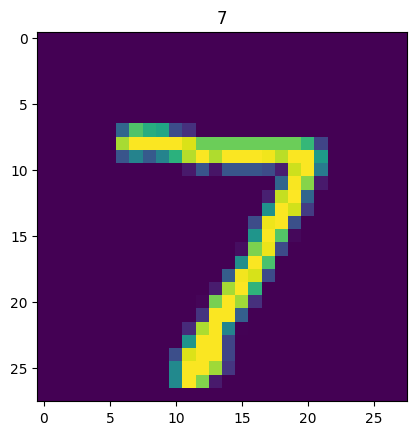

In [6]:
plt.imshow(test_data[0][0].reshape(28,28))
plt.title(test_data[0][1])
plt.show()

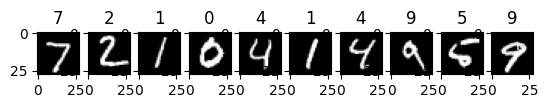

In [7]:
for i in range(10):
  plt.subplot(1,10,i+1)
  plt.imshow(test_data[i][0].reshape(28,28), cmap='gray')
  plt.title(test_data[i][-1])

## 2-3. 배치 구성과 입력 형태 확인

모든 이미지를 한 번에 처리하면 메모리 부담이 커집니다. 여기서는 50장씩 나누어 처리하고, 그 묶음에서 계산한 손실을 바탕으로 가중치를 업데이트합니다. 이 묶음이 batch입니다.

DataLoader는 이미지와 정답을 배치 단위로 꺼내 주는 도구입니다. 학습 때는 이미지 순서를 섞고, 테스트 때는 순서를 유지합니다. 마지막 배치에는 남은 이미지 수에 따라 50장보다 적게 들어갈 수 있습니다.

한 배치를 꺼내 이미지 형태를 확인합니다. `[50, 1, 28, 28]`은 **이미지 50장, 장마다 채널 1개, 세로 28칸, 가로 28칸**이라는 뜻입니다.

LSTM에는 `[50, 28, 28]`로 바꿔 넣습니다. 이때는 **이미지 50장, 장마다 읽을 행 28개, 한 행의 픽셀 28개**로 해석합니다. 숫자 데이터는 같지만 모델에 전달하는 형태와 각 차원의 역할이 달라집니다.

In [8]:
train_loader = torch.utils.data.DataLoader(dataset=train_data,
                                          batch_size=batch_size,
                                          shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                          batch_size=batch_size,
                                          shuffle=False)

In [9]:
# cf) Check dataloader shape
image, label = next(iter(test_loader))
print(image.size()) # [Batch, Channel, Height, Width]

torch.Size([50, 1, 28, 28])


## 2-4. LSTM으로 이미지를 읽고 분류하기

LSTM은 현재 행의 픽셀과 이전 단계의 상태를 함께 받아 다음 상태를 계산합니다. 이렇게 행을 따라 전달되는 정보가 hidden state입니다. LSTM에는 정보를 유지하고 조절하는 데 쓰는 cell state도 있습니다. 각 배치의 첫 행에서는 앞서 읽은 행이 없으므로 두 상태를 0으로 시작합니다.

여러 이미지를 함께 처리해도 이미지끼리 상태를 공유하는 것은 아닙니다. 이미지마다 별도의 상태를 유지하며, 28개 행을 읽는 동안 같은 모델 가중치를 사용합니다.

입력은 `[이미지 수, 읽을 행 수, 한 행의 픽셀 수]`입니다. `batch_first=True`는 LSTM이 이 순서로 입력을 받도록 지정합니다. 50장이라면 `[50, 28, 28]`입니다.

LSTM은 각 행을 읽은 결과를 출력하므로 `[50, 28, 128]`의 값이 나옵니다. 이 코드는 그중 **마지막 행까지 읽은 결과**만 선택합니다. 이를 Linear 층에 넣으면 이미지마다 숫자 0~9에 대한 점수 10개가 만들어집니다.

**이미지의 행들 → LSTM으로 순서대로 처리 → 마지막 결과 → 숫자 10개의 점수**

CNN에서 추출한 특징 뒤에 분류 층을 붙이는 것처럼, 여기서는 LSTM의 결과 뒤에 분류 층을 붙입니다. `__init__`에는 필요한 층을 만들고, `forward`에는 이 데이터 흐름을 적습니다.

<details><summary>원본 코드에서 입력 크기가 연결되는 방식</summary>

생성자에 적힌 이름은 `intput_size`이지만, LSTM 층을 만들 때는 설정 셀의 `input_size`를 참조합니다. 현재 값은 같으며, 생성자에 전달하는 값만 바꾸면 입력 크기가 함께 바뀌는 구조는 아닙니다.

</details>

In [10]:
import torch.nn as nn
import torch.nn.functional as F

In [11]:
class RNN(nn.Module):
  def __init__(self, intput_size, hidden_size, num_layers, num_classes):
    super(RNN, self).__init__()
    self.hidden_size = hidden_size
    self.num_layers = num_layers
    self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    # set initial hidden states and cell states
    h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) # torch.size([10, 50, 128])
    c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device) # torch.size([10, 50, 128])

    #Forward propagate LSTM
    out, _  = self.lstm(x, (h0, c0)) # output: tensor [batch_size, seq_length, hidden_size]
    # lstm의 출력 형식: (hidden state, cell state)

    #Decode the hidden state of the last time step
    out = self.fc(out[:,-1,:])

    return out

model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

실습: LSTM과 기본 RNN의 성능 비교
1. 먼저 LSTM 모델로 학습과 테스트를 완료하고, 정확도와 학습 시간을 기록하세요. 아래 RNN 코드는 주석 처리된 상태로 두세요.
2. 완료 후 아래 코드의 주석을 해제하고 실행해 기본 RNN 모델로 변경하세요. optimizer도 다시 생성한 뒤 학습과 테스트를 진행하세요.
3. 학습률·층 수·hidden size·학습 횟수는 동일하게 유지하고, 두 모델의 정확도와 학습 시간을 비교하세요.

In [ ]:
# class RNN(nn.Module):
#   def __init__(self, input_size, hidden_size, num_layers, num_classes):
#     super(RNN, self).__init__()
#     self.hidden_size = hidden_size
#     self.num_layers = num_layers

#     # 기본 RNN으로 각 행의 픽셀을 순서대로 처리
#     self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
#     self.fc = nn.Linear(hidden_size, num_classes)

#   def forward(self, x):
#     # 처음에는 앞에서 읽은 정보가 없으므로 상태를 0으로 초기화
#     h0 = x.new_zeros(self.num_layers, x.size(0), self.hidden_size)

#     # 기본 RNN은 hidden state만 사용
#     out, _ = self.rnn(x, h0)

#     # 마지막 행까지 읽은 결과로 숫자 10개의 점수 계산
#     out = self.fc(out[:, -1, :])
#     return out

# model = RNN(input_size, hidden_size, num_layers, num_classes).to(device)

## 2-5. 손실 함수와 optimizer

모델은 숫자를 바로 출력하는 대신, 0~9 각각에 대한 점수를 출력합니다. 손실 함수는 이 점수들과 정답 번호를 비교해 학습에 사용할 오차를 계산합니다. 이번에는 여러 클래스 중 하나를 고르는 분류이므로 `CrossEntropyLoss`를 사용합니다. 이 함수에는 softmax를 따로 적용하지 않은 점수를 넣습니다.

Adam은 계산한 기울기로 모델의 가중치를 수정하는 optimizer입니다. 아래에서는 LSTM과 분류 층의 가중치를 모두 학습 대상으로 연결합니다.

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## 2-6. 모델 학습

한 배치의 이미지를 가져오면 먼저 LSTM이 읽을 형태로 바꿉니다. 그다음 모델이 숫자별 점수를 내고, 정답과 비교해 손실을 계산합니다. 여기부터의 학습 과정은 MLP·CNN과 같습니다.

**예측 → 손실 계산 → 기울기 계산 → 가중치 업데이트**

PyTorch에서는 기울기가 누적되므로 `zero_grad()`로 이전 값을 지운 뒤 `backward()`로 이번 손실의 기울기를 구합니다. `step()`이 그 결과를 이용해 실제 가중치를 수정합니다.

이 과정을 전체 학습 이미지에 대해 한 번 수행하면 1 Epoch입니다. 여기서는 3 Epoch를 진행합니다. 출력되는 Step은 처리한 배치 수이고, Loss는 그 시점의 한 배치에서 계산한 손실입니다. Epoch 전체의 평균은 아닙니다.

In [13]:
####### Train #######
total_step = len(train_loader)
for epoch in range(num_epochs):
  for i, (image, label) in enumerate(train_loader):
    image = image.reshape(-1, sequence_length, input_size).to(device)
    label = label.to(device)

    # Forward
    output = model(image)
    loss = criterion(output, label)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1) % 400 == 0:
      print("Epoch [{}/{}], Step[{}/{}], Loss:{:.4f}".format(epoch+1, num_epochs, i+1, total_step, loss.item()))

Epoch [1/3], Step[400/1200], Loss:0.6931
Epoch [1/3], Step[800/1200], Loss:0.4314
Epoch [1/3], Step[1200/1200], Loss:0.1315
Epoch [2/3], Step[400/1200], Loss:0.2004
Epoch [2/3], Step[800/1200], Loss:0.0429
Epoch [2/3], Step[1200/1200], Loss:0.0663
Epoch [3/3], Step[400/1200], Loss:0.1644
Epoch [3/3], Step[800/1200], Loss:0.1393
Epoch [3/3], Step[1200/1200], Loss:0.0737


### 테스트 정확도 확인

학습에 쓰지 않은 테스트 이미지를 모델에 넣습니다. 이미지마다 점수 10개 중 가장 높은 위치를 예측 숫자로 선택하고 정답과 비교합니다. 전체 이미지 중 맞힌 비율을 백분율로 표시한 값이 정확도입니다.

테스트에서는 가중치를 수정하지 않으므로 기울기도 필요하지 않습니다. `no_grad()` 안에서 계산하면 불필요한 역전파 준비를 생략할 수 있습니다.

이 모델에는 Dropout이나 BatchNorm이 없어, 원본에서 생략된 `model.eval()`에 따른 해당 층의 동작 차이는 없습니다.

In [14]:
######## TEST ########
with torch.no_grad():
  correct = 0

  for image, label in test_loader:
    image = image.reshape(-1, sequence_length, input_size).to(device)
    label = label.to(device)
    output = model(image)
    _, pred = torch.max(output.data, 1)
    correct += (pred == label).sum().item()

  print('Test Accuracy of RNN model on the {} test images: {}%'.format(len(test_data), 100 * correct / len(test_data)))

Test Accuracy of RNN model on the 10000 test images: 97.45%
